# Fase 4: Transfer Learning
## Comparación con ResNet50 preentrenada

Cargamos ResNet50 con pesos de ImageNet, congelamos las capas base y añadimos un clasificador para las 4 clases.

In [19]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sys.path.append(os.path.abspath(".."))
from src.utils.config import (
    TRAINING_DIR, IMG_SIZE, BATCH_SIZE, EPOCHS, MODELS_DIR, CLASSES
)
from src.data.loader import load_image_paths, load_and_preprocess_image
from src.data.preprocessing import encode_labels, split_dataset
from src.data.augmentation import get_tf_generators
from src.evaluation.metrics import evaluate_model
from src.evaluation.plots import plot_training_history, plot_confusion_matrix

%matplotlib inline

In [20]:
print("Cargando imágenes...")
train_paths, train_labels = load_image_paths(TRAINING_DIR)

X = []
y = []
for path, label in zip(train_paths, train_labels):
    img = load_and_preprocess_image(path, IMG_SIZE)
    if img is not None:
        X.append(img)
        y.append(label)

X = np.array(X)
y = encode_labels(np.array(y))
print(f"Imágenes cargadas: {X.shape}")

Cargando imágenes...
Imágenes cargadas: (5600, 128, 128, 3)


In [21]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
train_ds, val_ds, test_ds = get_tf_generators(
    X_train, X_val, X_test, y_train, y_val, y_test
)

In [22]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODELS_DIR, 'resnet50_finetuned.keras'),
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
]

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3536 - loss: 1.3480 - val_accuracy: 0.5774 - val_loss: 1.1836 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 976ms/step - accuracy: 0.4556 - loss: 1.1891 - val_accuracy: 0.5024 - val_loss: 1.1281 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4941 - loss: 1.1505 - val_accuracy: 0.6107 - val_loss: 1.0788 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5247 - loss: 1.1194 - val_accuracy: 0.6190 - val_loss: 1.0451 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5454 - loss: 1.0749 - val_accuracy: 0.6250 - val_loss: 0.9975 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5666 - loss: 1.0470 - val_accuracy: 0.6333 - val_loss: 0.9821 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5750 - loss: 1.0273 - val_accurac

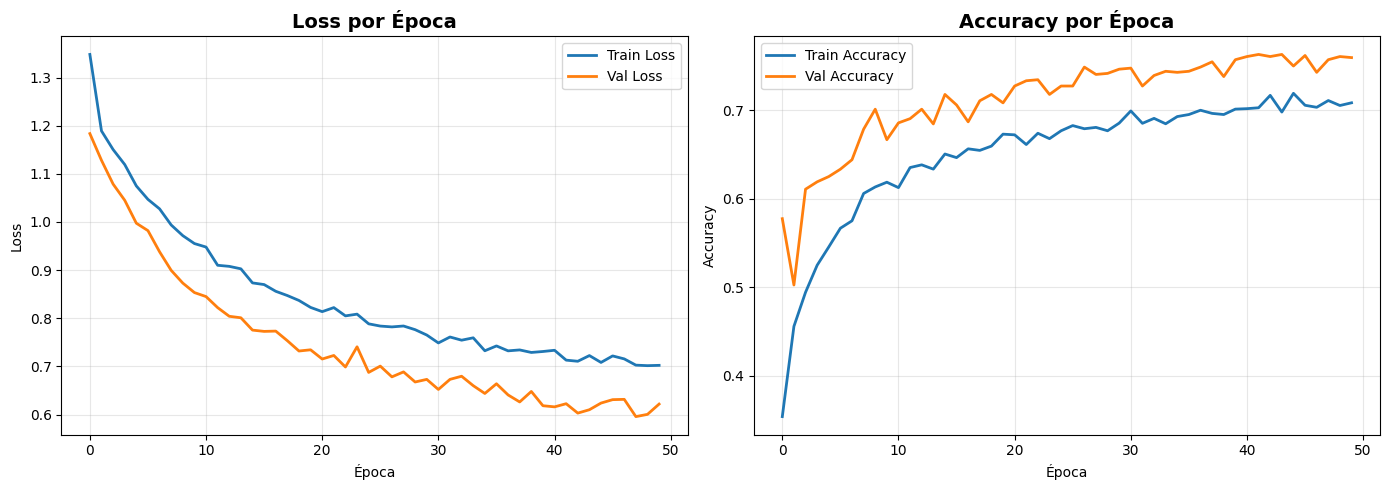

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step
MÉTRICAS TRANSFER LEARNING
Accuracy:  0.7357
Precision: 0.7438
Recall:    0.7357
F1-Score:  0.7227


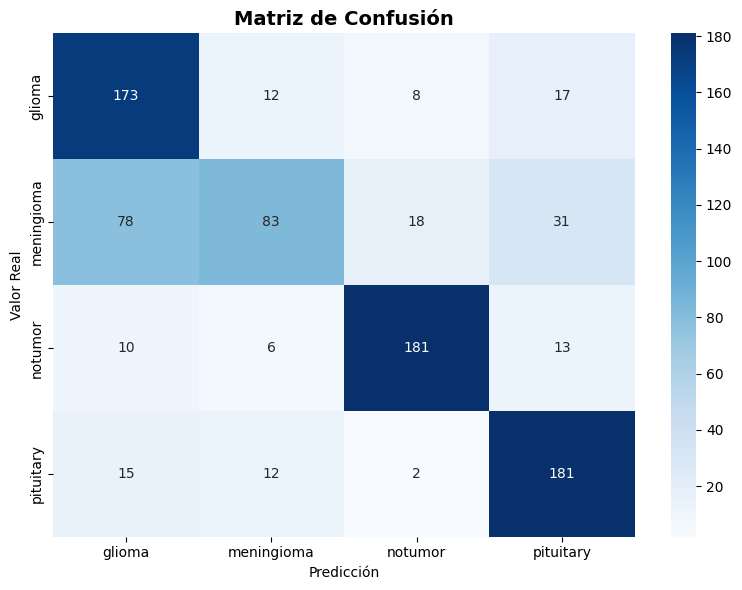

In [24]:
plot_training_history(history, '../docs/transfer_learning_curvas.png')

global_metrics, per_class, cm = evaluate_model(model, X_test, y_test)

print("MÉTRICAS TRANSFER LEARNING")
print(f"Accuracy:  {global_metrics['accuracy']:.4f}")
print(f"Precision: {global_metrics['precision']:.4f}")
print(f"Recall:    {global_metrics['recall']:.4f}")
print(f"F1-Score:  {global_metrics['f1_score']:.4f}")

plot_confusion_matrix(cm, '../docs/transfer_learning_confusion.png')

In [25]:
model.save(os.path.join(MODELS_DIR, 'resnet50_finetuned.keras'))
print("Modelo guardado en models/resnet50_finetuned.keras")

Modelo guardado en models/resnet50_finetuned.keras
